CALM-CXR  Integrated Pipeline

In [1]:
# Optional Colab setup
!pip install -q scikit-learn matplotlib opencv-python

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:

from __future__ import annotations

import os
import json
import math
import random
import time
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Sequence, Any

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
import torchvision.models as tvm
from torchvision.models import (
    ResNet18_Weights,
    ResNet50_Weights,
    ConvNeXt_Tiny_Weights,
)

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
)

try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except Exception:
    HAS_PLT = False

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass
class Config:
    # Paths
    image_root: str = "/content/drive/MyDrive/Lung_data/img"
    mask_root: str = "/content/drive/MyDrive/Lung_data/mask"
    output_dir: str = "/content/drive/MyDrive/mearnet_reproducible_outputs"

    # Labels must match folder names
    classes3: Tuple[str, str, str] = ("bacteria", "normal", "virus")

    # Data and split
    img_size: int = 224
    train_ratio: float = 0.70
    val_ratio: float = 0.10
    calib_ratio: float = 0.10
    test_ratio: float = 0.10
    seed: int = 42

    # Mode
    mode: str = "two_stage"  # "single" or "two_stage"
    enhance_on_fly: bool = False  # lightweight ASCE-like enhancement during loading

    # Backbone/model
    backbone: str = "convnext_tiny"  # "convnext_tiny", "resnet18", "resnet50"
    grid_size: int = 7
    num_experts: int = 3
    expert_dim: int = 256
    router_hidden: int = 256
    mc_samples: int = 6
    dropout: float = 0.20
    use_uncertainty_temperature: bool = True
    t_min: float = 0.70
    t_max: float = 1.50

    # Training
    batch_size: int = 16
    num_workers: int = 2
    epochs_single: int = 20
    epochs_s1: int = 12
    epochs_s2: int = 12
    freeze_backbone_epochs: int = 3  # freeze first N epochs, then unfreeze
    lr_backbone: float = 1e-5
    lr_head: float = 2e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05
    use_weighted_sampler: bool = True
    amp: bool = True

    # Loss weights
    lambda_anat: float = 0.05
    lambda_router_entropy: float = 0.01
    lambda_conflict: float = 0.01

    # Calibration / evaluation
    tta_flip: bool = False  # keep False for primary CXR reporting; use True only as ablation
    n_bootstrap: int = 500

    # Runtime
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def ensure_dir(path: str | Path) -> Path:
    p = Path(path)
    p.mkdir(parents=True, exist_ok=True)
    return p


def save_json(obj: Any, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)




IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def list_image_samples(image_root: str, classes3: Sequence[str]) -> List[Tuple[str, int, str]]:
    """Return list of (image_path, y3, class_name)."""
    root = Path(image_root)
    if not root.exists():
        raise FileNotFoundError(f"image_root not found: {image_root}")

    samples: List[Tuple[str, int, str]] = []
    for y, cname in enumerate(classes3):
        cdir = root / cname
        if not cdir.exists():
            raise FileNotFoundError(f"Expected class folder not found: {cdir}")
        for p in sorted(cdir.rglob("*")):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                samples.append((str(p), y, cname))
    if len(samples) == 0:
        raise RuntimeError(f"No images found under {image_root}")
    return samples


def build_mask_index(mask_root: str) -> Dict[str, str]:
    """Index masks by file stem. If duplicate stems exist, the first sorted path is used."""
    root = Path(mask_root)
    mask_map: Dict[str, str] = {}
    if not root.exists():
        return mask_map
    for p in sorted(root.rglob("*")):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            mask_map.setdefault(p.stem, str(p))
    return mask_map


def stratified_four_way_split(
    labels: Sequence[int],
    train_ratio: float,
    val_ratio: float,
    calib_ratio: float,
    test_ratio: float,
    seed: int,
) -> Dict[str, List[int]]:
    """Stratified train/val/calib/test split."""
    total = train_ratio + val_ratio + calib_ratio + test_ratio
    if abs(total - 1.0) > 1e-6:
        raise ValueError("Split ratios must sum to 1.0")

    labels = np.asarray(labels)
    indices = np.arange(len(labels))

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=(1 - train_ratio), random_state=seed)
    train_idx, rem_idx = next(sss1.split(indices, labels))

    rem_labels = labels[rem_idx]
    rem_total = val_ratio + calib_ratio + test_ratio
    val_rel = val_ratio / rem_total

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=(1 - val_rel), random_state=seed + 1)
    val_part, rem2_part = next(sss2.split(rem_idx, rem_labels))
    val_idx = rem_idx[val_part]
    rem2_idx = rem_idx[rem2_part]

    rem2_labels = labels[rem2_idx]
    calib_rel = calib_ratio / (calib_ratio + test_ratio)

    sss3 = StratifiedShuffleSplit(n_splits=1, test_size=(1 - calib_rel), random_state=seed + 2)
    calib_part, test_part = next(sss3.split(rem2_idx, rem2_labels))
    calib_idx = rem2_idx[calib_part]
    test_idx = rem2_idx[test_part]

    return {
        "train": train_idx.tolist(),
        "val": val_idx.tolist(),
        "calib": calib_idx.tolist(),
        "test": test_idx.tolist(),
    }


def read_pil_rgb(path: str) -> Image.Image:
    return Image.open(path).convert("RGB")


def read_mask_pil(path: Optional[str], size: int) -> Image.Image:
    """
    Return binary-like mask PIL image. If mask is missing, all-ones mask is used.
    This avoids label leakage from mask availability.
    """
    if path is None or not Path(path).exists():
        arr = np.full((size, size), 255, dtype=np.uint8)
        return Image.fromarray(arr, mode="L")
    m = Image.open(path).convert("L")
    return m


def asce_like_enhancement(img: Image.Image, mask: Image.Image) -> Image.Image:
    """
    Lightweight ASCE-like enhancement for reproducibility.
    It applies CLAHE and gentle sharpening inside the lung mask.
    If cv2 is unavailable, returns the original image.
    """
    if not HAS_CV2:
        return img

    img_np = np.array(img.convert("RGB"))
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    mask_np = np.array(mask.resize(img.size).convert("L"))
    mask_bin = (mask_np > 20).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enh = clahe.apply(gray)
    smooth = cv2.bilateralFilter(enh, d=5, sigmaColor=35, sigmaSpace=35)
    sharp = cv2.addWeighted(enh, 1.35, smooth, -0.35, 0)

    out = gray.copy()
    out[mask_bin == 1] = sharp[mask_bin == 1]
    out_rgb = cv2.cvtColor(out, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(out_rgb)


class CXRDataset(Dataset):
    """
    Base dataset that can serve single-stage, Stage-1, or Stage-2 tasks.

    y3 mapping: bacteria=0, normal=1, virus=2
    stage1 mapping: normal=0, abnormal=1
    stage2 mapping: bacteria=0, virus=1; normal samples are excluded by indices.
    """

    def __init__(
        self,
        image_root: str,
        mask_root: str,
        classes3: Sequence[str],
        indices: Optional[Sequence[int]] = None,
        task: str = "single3",
        img_size: int = 224,
        enhance_on_fly: bool = False,
    ):
        super().__init__()
        self.all_samples = list_image_samples(image_root, classes3)
        self.mask_map = build_mask_index(mask_root)
        self.classes3 = tuple(classes3)
        self.task = task
        self.img_size = img_size
        self.enhance_on_fly = enhance_on_fly

        if indices is None:
            indices = list(range(len(self.all_samples)))
        if task == "stage2":
            # Keep only bacteria and virus.
            indices = [i for i in indices if self.all_samples[i][1] in (0, 2)]
        self.indices = list(indices)

        self.img_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])
        self.mask_tf = T.Compose([
            T.Resize((img_size, img_size), interpolation=T.InterpolationMode.NEAREST),
            T.ToTensor(),
        ])

    def __len__(self) -> int:
        return len(self.indices)

    def _mask_path_for_image(self, image_path: str) -> Optional[str]:
        stem = Path(image_path).stem
        return self.mask_map.get(stem, None)

    def __getitem__(self, i: int):
        base_idx = self.indices[i]
        img_path, y3, cname = self.all_samples[base_idx]
        mask_path = self._mask_path_for_image(img_path)

        img = read_pil_rgb(img_path)
        mask = read_mask_pil(mask_path, self.img_size)
        if self.enhance_on_fly:
            img = asce_like_enhancement(img, mask)

        x = self.img_tf(img)
        m = self.mask_tf(mask)
        m = (m > 0.05).float()

        if self.task == "single3":
            y = y3
        elif self.task == "stage1":
            y = 0 if y3 == 1 else 1  # normal=0, abnormal=1
        elif self.task == "stage2":
            if y3 == 0:
                y = 0  # bacteria
            elif y3 == 2:
                y = 1  # virus
            else:
                raise RuntimeError("Normal sample found in Stage-2 dataset")
        else:
            raise ValueError(f"Unknown task: {self.task}")

        return {
            "image": x,
            "mask": m,
            "label": torch.tensor(y, dtype=torch.long),
            "label3": torch.tensor(y3, dtype=torch.long),
            "fname": Path(img_path).name,
            "path": img_path,
            "base_idx": base_idx,
        }

    def labels_for_indices(self, indices: Optional[Sequence[int]] = None, task: Optional[str] = None) -> List[int]:
        if indices is None:
            indices = self.indices
        task = task or self.task
        ys = []
        for i in indices:
            y3 = self.all_samples[i][1]
            if task == "single3":
                y = y3
            elif task == "stage1":
                y = 0 if y3 == 1 else 1
            elif task == "stage2":
                if y3 == 0:
                    y = 0
                elif y3 == 2:
                    y = 1
                else:
                    continue
            ys.append(y)
        return ys


def make_loader(
    ds: CXRDataset,
    batch_size: int,
    num_workers: int,
    shuffle: bool = False,
    weighted: bool = False,
) -> DataLoader:
    sampler = None
    if weighted:
        labels = ds.labels_for_indices(ds.indices, ds.task)
        counts = np.bincount(labels, minlength=max(labels) + 1)
        weights_per_class = 1.0 / np.maximum(counts, 1)
        sample_weights = [weights_per_class[y] for y in labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle = False

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )


def class_weights_from_dataset(ds: CXRDataset, num_classes: int) -> torch.Tensor:
    labels = ds.labels_for_indices(ds.indices, ds.task)
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)
    weights = counts.sum() / np.maximum(counts, 1.0)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)



class BackboneFeatures(nn.Module):
    def __init__(self, backbone: str = "convnext_tiny", pretrained: bool = True):
        super().__init__()
        self.backbone = backbone.lower()
        if self.backbone == "convnext_tiny":
            weights = ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
            m = tvm.convnext_tiny(weights=weights)
            self.features = m.features
            self.out_channels = 768
        elif self.backbone == "resnet18":
            weights = ResNet18_Weights.DEFAULT if pretrained else None
            m = tvm.resnet18(weights=weights)
            self.features = nn.Sequential(m.conv1, m.bn1, m.relu, m.maxpool, m.layer1, m.layer2, m.layer3, m.layer4)
            self.out_channels = 512
        elif self.backbone == "resnet50":
            weights = ResNet50_Weights.DEFAULT if pretrained else None
            m = tvm.resnet50(weights=weights)
            self.features = nn.Sequential(m.conv1, m.bn1, m.relu, m.maxpool, m.layer1, m.layer2, m.layer3, m.layer4)
            self.out_channels = 2048
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.features(x)


class MaskGuidedGridExtractor(nn.Module):
    def __init__(self, in_channels: int, expert_dim: int, grid_size: int):
        super().__init__()
        self.grid_size = grid_size
        self.proj = nn.Sequential(
            nn.LayerNorm(in_channels),
            nn.Linear(in_channels, expert_dim),
            nn.GELU(),
            nn.Dropout(0.10),
        )

    @staticmethod
    def _resize_mask(mask: torch.Tensor, h: int, w: int) -> torch.Tensor:
        return F.interpolate(mask, size=(h, w), mode="nearest")

    def forward(self, feat: torch.Tensor, mask: torch.Tensor) -> Dict[str, torch.Tensor]:
        B, C, H, W = feat.shape
        m_feat = self._resize_mask(mask, H, W)
        feat_masked = feat * m_feat

        # Regional grid tokens from masked features.
        pooled = F.adaptive_avg_pool2d(feat_masked, (self.grid_size, self.grid_size))
        tokens = pooled.flatten(2).transpose(1, 2)  # [B, N, C]

        # Soft lung occupancy per grid cell.
        lung_grid = F.adaptive_avg_pool2d(m_feat, (self.grid_size, self.grid_size)).flatten(1)  # [B, N]
        lung_grid = lung_grid.clamp(0.0, 1.0)

        tokens = self.proj(tokens)

        denom = lung_grid.sum(dim=1, keepdim=True).clamp_min(1e-6)
        global_context = (tokens * lung_grid.unsqueeze(-1)).sum(dim=1) / denom

        return {
            "tokens": tokens,
            "lung_grid": lung_grid,
            "global_context": global_context,
            "feat_masked": feat_masked,
        }


class UncertaintyRouter(nn.Module):
    def __init__(self, expert_dim: int, num_experts: int, hidden: int, dropout: float):
        super().__init__()
        self.num_experts = num_experts
        self.net = nn.Sequential(
            nn.Linear(expert_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_experts),
        )

    def forward(self, tokens: torch.Tensor, mc_samples: int = 1) -> Dict[str, torch.Tensor]:
        probs = []
        # Keep dropout active for MC routing uncertainty.
        was_training = self.training
        if mc_samples > 1:
            self.train(True)
        for _ in range(max(1, mc_samples)):
            logits = self.net(tokens)
            probs.append(F.softmax(logits, dim=-1))
        self.train(was_training)

        stack = torch.stack(probs, dim=0)  # [S, B, N, K]
        mean_p = stack.mean(dim=0)
        var_p = stack.var(dim=0, unbiased=False)
        entropy = -(mean_p * (mean_p.clamp_min(1e-8)).log()).sum(dim=-1)  # [B,N]
        epistemic = var_p.sum(dim=-1)  # [B,N]
        top_expert = mean_p.argmax(dim=-1)
        return {
            "routing_probs": mean_p,
            "routing_var": var_p,
            "routing_entropy": entropy,
            "epistemic": epistemic,
            "top_expert": top_expert,
        }


class ExpertBank(nn.Module):
    def __init__(
        self,
        expert_dim: int,
        num_experts: int,
        t_min: float = 0.7,
        t_max: float = 1.5,
        use_uncertainty_temperature: bool = True,
    ):
        super().__init__()
        self.num_experts = num_experts
        self.t_min = t_min
        self.t_max = t_max
        self.use_uncertainty_temperature = use_uncertainty_temperature
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(expert_dim, expert_dim),
                nn.GELU(),
                nn.Dropout(0.10),
                nn.Linear(expert_dim, expert_dim),
                nn.GELU(),
            )
            for _ in range(num_experts)
        ])

    def _uncertainty_temperature(self, u: torch.Tensor) -> torch.Tensor:
        # Normalize uncertainty within each batch item.
        u_min = u.min(dim=1, keepdim=True).values
        u_max = u.max(dim=1, keepdim=True).values
        un = (u - u_min) / (u_max - u_min + 1e-8)
        return self.t_min + (self.t_max - self.t_min) * un

    def forward(
        self,
        tokens: torch.Tensor,
        lung_grid: torch.Tensor,
        routing_probs: torch.Tensor,
        epistemic: torch.Tensor,
    ) -> torch.Tensor:
        # routing_probs: [B,N,K], tokens: [B,N,D], lung_grid: [B,N]
        if self.use_uncertainty_temperature:
            Tg = self._uncertainty_temperature(epistemic).unsqueeze(-1)  # [B,N,1]
            routing = F.softmax(torch.log(routing_probs.clamp_min(1e-8)) / Tg, dim=-1)
        else:
            routing = routing_probs

        expert_tokens = []
        for k, expert in enumerate(self.experts):
            w = routing[..., k] * lung_grid  # [B,N]
            denom = w.sum(dim=1, keepdim=True).clamp_min(1e-6)
            pooled = (tokens * w.unsqueeze(-1)).sum(dim=1) / denom
            expert_tokens.append(expert(pooled))
        return torch.stack(expert_tokens, dim=1)  # [B,K,D]


class CrossExpertConsultation(nn.Module):
    def __init__(self, expert_dim: int, num_heads: int = 4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=expert_dim, num_heads=num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(expert_dim)
        self.ffn = nn.Sequential(
            nn.Linear(expert_dim, expert_dim * 2),
            nn.GELU(),
            nn.Linear(expert_dim * 2, expert_dim),
        )
        self.norm2 = nn.LayerNorm(expert_dim)

    def forward(self, expert_tokens: torch.Tensor) -> torch.Tensor:
        a, _ = self.attn(expert_tokens, expert_tokens, expert_tokens, need_weights=False)
        x = self.norm1(expert_tokens + a)
        y = self.norm2(x + self.ffn(x))
        return y


class ClinicalReasoningHead(nn.Module):
    def __init__(self, expert_dim: int, num_classes: int, dropout: float = 0.20):
        super().__init__()
        in_dim = expert_dim * 2
        self.fusion = nn.Sequential(
            nn.Linear(in_dim, expert_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(expert_dim, expert_dim // 2),
            nn.GELU(),
        )
        self.logits = nn.Linear(expert_dim // 2, num_classes)
        self.aleatoric = nn.Sequential(nn.Linear(expert_dim // 2, 1), nn.Softplus())
        self.conflict = nn.Sequential(nn.Linear(expert_dim // 2, 1), nn.Sigmoid())

    def forward(self, expert_tokens: torch.Tensor, global_context: torch.Tensor) -> Dict[str, torch.Tensor]:
        expert_summary = expert_tokens.mean(dim=1)
        z = torch.cat([expert_summary, global_context], dim=-1)
        h = self.fusion(z)
        return {
            "logits": self.logits(h),
            "aleatoric": self.aleatoric(h).squeeze(-1),
            "conflict": self.conflict(h).squeeze(-1),
            "fused_feature": h,
        }


class MEARNet(nn.Module):
    def __init__(self, cfg: Config, num_classes: int):
        super().__init__()
        self.cfg = cfg
        self.num_classes = num_classes
        self.backbone = BackboneFeatures(cfg.backbone, pretrained=True)
        self.grid = MaskGuidedGridExtractor(self.backbone.out_channels, cfg.expert_dim, cfg.grid_size)
        self.router = UncertaintyRouter(cfg.expert_dim, cfg.num_experts, cfg.router_hidden, cfg.dropout)
        self.experts = ExpertBank(
            cfg.expert_dim,
            cfg.num_experts,
            t_min=cfg.t_min,
            t_max=cfg.t_max,
            use_uncertainty_temperature=cfg.use_uncertainty_temperature,
        )
        self.consult = CrossExpertConsultation(cfg.expert_dim)
        self.head = ClinicalReasoningHead(cfg.expert_dim, num_classes, cfg.dropout)

    def freeze_backbone(self, freeze: bool = True) -> None:
        for p in self.backbone.parameters():
            p.requires_grad = not freeze

    def forward(self, x: torch.Tensor, mask: torch.Tensor, mc_samples: Optional[int] = None) -> Dict[str, torch.Tensor]:
        if mc_samples is None:
            mc_samples = self.cfg.mc_samples
        feat = self.backbone(x)
        g = self.grid(feat, mask)
        r = self.router(g["tokens"], mc_samples=mc_samples)
        e = self.experts(g["tokens"], g["lung_grid"], r["routing_probs"], r["epistemic"])
        e2 = self.consult(e)
        h = self.head(e2, g["global_context"])
        out = {**h, **r, "lung_grid": g["lung_grid"], "expert_tokens": e2}
        return out



class MEARNetLoss(nn.Module):
    def __init__(self, class_weights: torch.Tensor, cfg: Config):
        super().__init__()
        self.register_buffer("class_weights", class_weights.float())
        self.cfg = cfg

    def forward(self, out: Dict[str, torch.Tensor], y: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, float]]:
        ce = F.cross_entropy(
            out["logits"],
            y,
            weight=self.class_weights,
            label_smoothing=self.cfg.label_smoothing,
        )
        lung = out["lung_grid"]
        entropy = out["routing_entropy"]
        max_route = out["routing_probs"].max(dim=-1).values

        in_denom = lung.sum().clamp_min(1e-6)
        out_denom = (1.0 - lung).sum().clamp_min(1e-6)
        router_entropy_loss = (entropy * lung).sum() / in_denom
        anatomy_loss = (max_route * (1.0 - lung)).sum() / out_denom
        conflict_loss = out["conflict"].mean()

        total = (
            ce
            + self.cfg.lambda_anat * anatomy_loss
            + self.cfg.lambda_router_entropy * router_entropy_loss
            + self.cfg.lambda_conflict * conflict_loss
        )
        parts = {
            "loss": float(total.detach().cpu()),
            "ce": float(ce.detach().cpu()),
            "anat": float(anatomy_loss.detach().cpu()),
            "router_entropy": float(router_entropy_loss.detach().cpu()),
            "conflict": float(conflict_loss.detach().cpu()),
        }
        return total, parts


def build_optimizer(model: MEARNet, cfg: Config) -> torch.optim.Optimizer:
    backbone_params = list(model.backbone.parameters())
    head_params = [p for n, p in model.named_parameters() if not n.startswith("backbone.")]
    return torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": cfg.lr_backbone},
            {"params": head_params, "lr": cfg.lr_head},
        ],
        weight_decay=cfg.weight_decay,
    )


def train_one_epoch(
    model: MEARNet,
    loader: DataLoader,
    criterion: MEARNetLoss,
    optimizer: torch.optim.Optimizer,
    device: str,
    amp: bool = True,
) -> Dict[str, float]:
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
    totals: Dict[str, float] = {}
    n = 0
    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        m = batch["mask"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):
            out = model(x, m)
            loss, parts = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        n += bs
        for k, v in parts.items():
            totals[k] = totals.get(k, 0.0) + v * bs
    return {k: v / max(n, 1) for k, v in totals.items()}


@torch.no_grad()
def collect_logits(
    model: MEARNet,
    loader: DataLoader,
    device: str,
    tta_flip: bool = False,
    temperature: float = 1.0,
) -> Dict[str, np.ndarray]:
    model.eval()
    logits_all, probs_all, y_all, y3_all, idx_all = [], [], [], [], []
    names: List[str] = []

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        m = batch["mask"].to(device, non_blocking=True)
        y = batch["label"].cpu().numpy()
        y3 = batch["label3"].cpu().numpy()
        idx = batch["base_idx"].cpu().numpy()

        out1 = model(x, m, mc_samples=1)
        logits = out1["logits"]
        probs = F.softmax(logits / max(temperature, 1e-6), dim=1)

        if tta_flip:
            xf = torch.flip(x, dims=[3])
            mf = torch.flip(m, dims=[3])
            out2 = model(xf, mf, mc_samples=1)
            logits2 = out2["logits"]
            probs2 = F.softmax(logits2 / max(temperature, 1e-6), dim=1)
            probs = 0.5 * (probs + probs2)
            logits = torch.log(probs.clamp_min(1e-8))

        logits_all.append(logits.detach().cpu().numpy())
        probs_all.append(probs.detach().cpu().numpy())
        y_all.append(y)
        y3_all.append(y3)
        idx_all.append(idx)
        names.extend(batch["fname"])

    return {
        "logits": np.concatenate(logits_all, axis=0),
        "probs": np.concatenate(probs_all, axis=0),
        "y": np.concatenate(y_all, axis=0),
        "y3": np.concatenate(y3_all, axis=0),
        "base_idx": np.concatenate(idx_all, axis=0),
        "fname": np.array(names),
    }


def evaluate_for_selection(model: MEARNet, loader: DataLoader, device: str) -> Dict[str, float]:
    pack = collect_logits(model, loader, device, tta_flip=False, temperature=1.0)
    y, probs = pack["y"], pack["probs"]
    pred = probs.argmax(axis=1)
    return {
        "acc": float(accuracy_score(y, pred)),
        "macro_f1": float(f1_score(y, pred, average="macro")),
    }


def fit_model(
    model: MEARNet,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: MEARNetLoss,
    cfg: Config,
    epochs: int,
    ckpt_path: str | Path,
) -> Dict[str, Any]:
    device = cfg.device
    model.to(device)
    optimizer = build_optimizer(model, cfg)
    ckpt_path = Path(ckpt_path)
    best_f1 = -1.0
    history = []

    for epoch in range(1, epochs + 1):
        if cfg.freeze_backbone_epochs > 0:
            model.freeze_backbone(epoch <= cfg.freeze_backbone_epochs)

        t0 = time.time()
        tr = train_one_epoch(model, train_loader, criterion, optimizer, device, cfg.amp)
        va = evaluate_for_selection(model, val_loader, device)
        row = {"epoch": epoch, **{f"train_{k}": v for k, v in tr.items()}, **{f"val_{k}": v for k, v in va.items()}, "sec": time.time() - t0}
        history.append(row)
        print(f"Epoch {epoch:03d}/{epochs} | loss={tr['loss']:.4f} | val_acc={va['acc']:.4f} | val_f1={va['macro_f1']:.4f}")

        if va["macro_f1"] > best_f1:
            best_f1 = va["macro_f1"]
            ckpt_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model": model.state_dict(), "cfg": asdict(cfg), "best_f1": best_f1, "epoch": epoch}, ckpt_path)

    # reload best
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state["model"])
    return {"best_f1": best_f1, "history": history, "ckpt": str(ckpt_path)}




class TemperatureScaler:
    def __init__(self):
        self.temperature: float = 1.0

    def fit(self, logits: np.ndarray, labels: np.ndarray, max_iter: int = 50) -> float:
        device = "cuda" if torch.cuda.is_available() else "cpu"
        z = torch.tensor(logits, dtype=torch.float32, device=device)
        y = torch.tensor(labels, dtype=torch.long, device=device)
        log_T = torch.zeros(1, requires_grad=True, device=device)
        opt = torch.optim.LBFGS([log_T], lr=0.05, max_iter=max_iter, line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad()
            Tval = torch.exp(log_T).clamp(0.05, 20.0)
            loss = F.cross_entropy(z / Tval, y)
            loss.backward()
            return loss

        opt.step(closure)
        self.temperature = float(torch.exp(log_T).detach().cpu().clamp(0.05, 20.0))
        return self.temperature


def ece_score(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(np.float32)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if mask.any():
            ece += (mask.mean()) * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)


def multiclass_brier(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    yoh = np.eye(num_classes)[labels]
    return float(np.mean(np.sum((probs - yoh) ** 2, axis=1)))


def macro_pr_auc(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    yoh = np.eye(num_classes)[labels]
    vals = []
    for c in range(num_classes):
        if len(np.unique(yoh[:, c])) > 1:
            vals.append(average_precision_score(yoh[:, c], probs[:, c]))
    return float(np.mean(vals)) if vals else float("nan")


def safe_roc_auc(probs: np.ndarray, labels: np.ndarray, num_classes: int) -> float:
    try:
        if num_classes == 2:
            return float(roc_auc_score(labels, probs[:, 1]))
        return float(roc_auc_score(labels, probs, multi_class="ovr", average="macro"))
    except Exception:
        return float("nan")


def compute_metrics(
    probs: np.ndarray,
    labels: np.ndarray,
    class_names: Sequence[str],
    pred: Optional[np.ndarray] = None,
) -> Dict[str, Any]:
    num_classes = len(class_names)
    if pred is None:
        pred = probs.argmax(axis=1)
    metrics = {
        "accuracy": float(accuracy_score(labels, pred)),
        "macro_f1": float(f1_score(labels, pred, average="macro")),
        "weighted_f1": float(f1_score(labels, pred, average="weighted")),
        "roc_auc": safe_roc_auc(probs, labels, num_classes),
        "pr_auc_macro": macro_pr_auc(probs, labels, num_classes),
        "ece": ece_score(probs, labels),
        "brier": multiclass_brier(probs, labels, num_classes),
        "nll": float(log_loss(labels, probs, labels=list(range(num_classes)))),
        "confusion_matrix": confusion_matrix(labels, pred).tolist(),
        "classification_report": classification_report(labels, pred, target_names=list(class_names), output_dict=True, zero_division=0),
    }
    return metrics


def bootstrap_ci(
    probs: np.ndarray,
    labels: np.ndarray,
    class_names: Sequence[str],
    pred: Optional[np.ndarray] = None,
    n_bootstrap: int = 500,
    seed: int = 42,
) -> Dict[str, Tuple[float, float]]:
    rng = np.random.default_rng(seed)
    n = len(labels)
    accs, f1s = [], []
    if pred is None:
        pred = probs.argmax(axis=1)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        accs.append(accuracy_score(labels[idx], pred[idx]))
        f1s.append(f1_score(labels[idx], pred[idx], average="macro"))
    return {
        "accuracy_95ci": (float(np.percentile(accs, 2.5)), float(np.percentile(accs, 97.5))),
        "macro_f1_95ci": (float(np.percentile(f1s, 2.5)), float(np.percentile(f1s, 97.5))),
    }


def tune_binary_threshold(probs: np.ndarray, labels: np.ndarray, metric: str = "macro_f1") -> Tuple[float, float]:
    """Tune threshold for positive class probability."""
    best_t, best_val = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 181):
        pred = (probs[:, 1] >= t).astype(int)
        if metric == "macro_f1":
            val = f1_score(labels, pred, average="macro")
        else:
            val = accuracy_score(labels, pred)
        if val > best_val:
            best_t, best_val = float(t), float(val)
    return best_t, best_val



def prepare_splits(cfg: Config) -> Tuple[List[Tuple[str, int, str]], Dict[str, List[int]]]:
    samples = list_image_samples(cfg.image_root, cfg.classes3)
    labels = [s[1] for s in samples]
    splits = stratified_four_way_split(labels, cfg.train_ratio, cfg.val_ratio, cfg.calib_ratio, cfg.test_ratio, cfg.seed)
    return samples, splits


def dataset_summary(samples: List[Tuple[str, int, str]], splits: Dict[str, List[int]], classes3: Sequence[str]) -> Dict[str, Any]:
    out = {"total": len(samples), "classes": list(classes3), "splits": {}}
    labels = np.array([s[1] for s in samples])
    for k, idx in splits.items():
        counts = {classes3[c]: int((labels[idx] == c).sum()) for c in range(len(classes3))}
        out["splits"][k] = {"n": len(idx), "counts": counts}
    return out


def make_task_datasets(cfg: Config, splits: Dict[str, List[int]], task: str) -> Dict[str, CXRDataset]:
    return {
        k: CXRDataset(
            cfg.image_root,
            cfg.mask_root,
            cfg.classes3,
            indices=v,
            task=task,
            img_size=cfg.img_size,
            enhance_on_fly=cfg.enhance_on_fly,
        )
        for k, v in splits.items()
    }


def run_single_stage(cfg: Config) -> Dict[str, Any]:
    set_seed(cfg.seed)
    outdir = ensure_dir(Path(cfg.output_dir) / "single_stage")
    samples, splits = prepare_splits(cfg)
    save_json(asdict(cfg), outdir / "config.json")
    save_json(splits, outdir / "splits.json")
    save_json(dataset_summary(samples, splits, cfg.classes3), outdir / "dataset_summary.json")

    dsets = make_task_datasets(cfg, splits, task="single3")
    train_loader = make_loader(dsets["train"], cfg.batch_size, cfg.num_workers, weighted=cfg.use_weighted_sampler)
    val_loader = make_loader(dsets["val"], cfg.batch_size, cfg.num_workers)
    calib_loader = make_loader(dsets["calib"], cfg.batch_size, cfg.num_workers)
    test_loader = make_loader(dsets["test"], cfg.batch_size, cfg.num_workers)

    model = MEARNet(cfg, num_classes=3)
    cw = class_weights_from_dataset(dsets["train"], num_classes=3).to(cfg.device)
    criterion = MEARNetLoss(cw, cfg)
    train_info = fit_model(model, train_loader, val_loader, criterion, cfg, cfg.epochs_single, outdir / "best_single.pt")

    cal_raw = collect_logits(model, calib_loader, cfg.device, tta_flip=False, temperature=1.0)
    scaler = TemperatureScaler()
    Tstar = scaler.fit(cal_raw["logits"], cal_raw["y"])
    print(f"Learned temperature single-stage: T={Tstar:.4f}")

    test_pack = collect_logits(model, test_loader, cfg.device, tta_flip=cfg.tta_flip, temperature=Tstar)
    metrics = compute_metrics(test_pack["probs"], test_pack["y"], cfg.classes3)
    metrics["bootstrap"] = bootstrap_ci(test_pack["probs"], test_pack["y"], cfg.classes3, n_bootstrap=cfg.n_bootstrap, seed=cfg.seed)
    metrics["temperature"] = Tstar
    metrics["train_info"] = train_info
    save_json(metrics, outdir / "single_stage_test_metrics.json")
    print(json.dumps({k: metrics[k] for k in ["accuracy", "macro_f1", "roc_auc", "pr_auc_macro", "ece", "brier", "nll"]}, indent=2))
    return metrics


def run_two_stage(cfg: Config) -> Dict[str, Any]:
    set_seed(cfg.seed)
    outdir = ensure_dir(Path(cfg.output_dir) / "two_stage")
    samples, splits = prepare_splits(cfg)
    save_json(asdict(cfg), outdir / "config.json")
    save_json(splits, outdir / "splits.json")
    save_json(dataset_summary(samples, splits, cfg.classes3), outdir / "dataset_summary.json")

    # Stage 1: normal vs abnormal
    s1_dsets = make_task_datasets(cfg, splits, task="stage1")
    s1_train = make_loader(s1_dsets["train"], cfg.batch_size, cfg.num_workers, weighted=cfg.use_weighted_sampler)
    s1_val = make_loader(s1_dsets["val"], cfg.batch_size, cfg.num_workers)
    s1_cal = make_loader(s1_dsets["calib"], cfg.batch_size, cfg.num_workers)
    s1_test = make_loader(s1_dsets["test"], cfg.batch_size, cfg.num_workers)

    s1 = MEARNet(cfg, num_classes=2)
    s1_cw = class_weights_from_dataset(s1_dsets["train"], num_classes=2).to(cfg.device)
    s1_crit = MEARNetLoss(s1_cw, cfg)
    s1_info = fit_model(s1, s1_train, s1_val, s1_crit, cfg, cfg.epochs_s1, outdir / "best_stage1.pt")

    s1_cal_pack = collect_logits(s1, s1_cal, cfg.device, tta_flip=False, temperature=1.0)
    s1_scaler = TemperatureScaler()
    T1 = s1_scaler.fit(s1_cal_pack["logits"], s1_cal_pack["y"])
    s1_cal_pack_T = collect_logits(s1, s1_cal, cfg.device, tta_flip=cfg.tta_flip, temperature=T1)
    t1, t1_score = tune_binary_threshold(s1_cal_pack_T["probs"], s1_cal_pack_T["y"])
    print(f"Stage-1 temperature={T1:.4f}, threshold={t1:.3f}, calib_macro_f1={t1_score:.4f}")

    # Stage 2: bacteria vs virus
    s2_dsets = make_task_datasets(cfg, splits, task="stage2")
    s2_train = make_loader(s2_dsets["train"], cfg.batch_size, cfg.num_workers, weighted=cfg.use_weighted_sampler)
    s2_val = make_loader(s2_dsets["val"], cfg.batch_size, cfg.num_workers)
    s2_cal = make_loader(s2_dsets["calib"], cfg.batch_size, cfg.num_workers)
    s2_test = make_loader(s2_dsets["test"], cfg.batch_size, cfg.num_workers)

    s2 = MEARNet(cfg, num_classes=2)
    s2_cw = class_weights_from_dataset(s2_dsets["train"], num_classes=2).to(cfg.device)
    s2_crit = MEARNetLoss(s2_cw, cfg)
    s2_info = fit_model(s2, s2_train, s2_val, s2_crit, cfg, cfg.epochs_s2, outdir / "best_stage2.pt")

    s2_cal_pack = collect_logits(s2, s2_cal, cfg.device, tta_flip=False, temperature=1.0)
    s2_scaler = TemperatureScaler()
    T2 = s2_scaler.fit(s2_cal_pack["logits"], s2_cal_pack["y"])
    s2_cal_pack_T = collect_logits(s2, s2_cal, cfg.device, tta_flip=cfg.tta_flip, temperature=T2)
    t2, t2_score = tune_binary_threshold(s2_cal_pack_T["probs"], s2_cal_pack_T["y"])
    print(f"Stage-2 temperature={T2:.4f}, threshold={t2:.3f}, calib_macro_f1={t2_score:.4f}")

    # Final untouched test evaluation using probability composition.
    s1_test_pack = collect_logits(s1, s1_test, cfg.device, tta_flip=cfg.tta_flip, temperature=T1)
    s2_test_pack = collect_logits(s2, s2_test, cfg.device, tta_flip=cfg.tta_flip, temperature=T2)

    # Map Stage-2 probabilities by base index.
    s2_prob_by_idx = {int(idx): p for idx, p in zip(s2_test_pack["base_idx"], s2_test_pack["probs"])}

    n = len(s1_test_pack["y3"])
    probs3 = np.zeros((n, 3), dtype=np.float32)  # bacteria, normal, virus
    pred3 = np.zeros(n, dtype=np.int64)
    y3 = s1_test_pack["y3"].astype(np.int64)

    for i in range(n):
        p1 = s1_test_pack["probs"][i]  # [P(normal), P(abnormal)]
        p_normal = float(p1[0])
        p_abn = float(p1[1])
        base_idx = int(s1_test_pack["base_idx"][i])

        if base_idx in s2_prob_by_idx:
            p2 = s2_prob_by_idx[base_idx]  # [P(bacteria), P(virus)]
        else:
            # For normal cases, Stage-2 is not defined; neutral split is used only for probability completeness.
            p2 = np.array([0.5, 0.5], dtype=np.float32)

        # Calibrated hierarchical probability composition.
        probs3[i, 1] = p_normal
        probs3[i, 0] = p_abn * float(p2[0])
        probs3[i, 2] = p_abn * float(p2[1])
        probs3[i] = probs3[i] / np.clip(probs3[i].sum(), 1e-8, None)

        # Thresholded decision rule.
        if p_abn < t1:
            pred3[i] = 1  # normal
        else:
            pred3[i] = 2 if float(p2[1]) >= t2 else 0

    metrics = compute_metrics(probs3, y3, cfg.classes3, pred=pred3)
    metrics["bootstrap"] = bootstrap_ci(probs3, y3, cfg.classes3, pred=pred3, n_bootstrap=cfg.n_bootstrap, seed=cfg.seed)
    metrics["stage1_temperature"] = T1
    metrics["stage2_temperature"] = T2
    metrics["stage1_threshold"] = t1
    metrics["stage2_threshold"] = t2
    metrics["stage1_train_info"] = s1_info
    metrics["stage2_train_info"] = s2_info

    # Stage-wise metrics on test
    metrics["stage1_test"] = compute_metrics(s1_test_pack["probs"], s1_test_pack["y"], ["normal", "abnormal"], pred=(s1_test_pack["probs"][:, 1] >= t1).astype(int))
    metrics["stage2_test"] = compute_metrics(s2_test_pack["probs"], s2_test_pack["y"], ["bacteria", "virus"], pred=(s2_test_pack["probs"][:, 1] >= t2).astype(int))

    # Error attribution
    s1_pred = (s1_test_pack["probs"][:, 1] >= t1).astype(int)
    s1_true = s1_test_pack["y"].astype(int)
    stage1_error = int((s1_pred != s1_true).sum())
    final_error = int((pred3 != y3).sum())
    metrics["error_attribution"] = {
        "final_errors": final_error,
        "stage1_errors": stage1_error,
        "post_routing_or_stage2_errors_estimated": max(final_error - stage1_error, 0),
    }

    save_json(metrics, outdir / "two_stage_test_metrics.json")
    print(json.dumps({k: metrics[k] for k in ["accuracy", "macro_f1", "roc_auc", "pr_auc_macro", "ece", "brier", "nll"]}, indent=2))
    return metrics




def plot_reliability(probs: np.ndarray, labels: np.ndarray, out_path: str | Path, n_bins: int = 10) -> None:
    if not HAS_PLT:
        return
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(np.float32)
    bins = np.linspace(0, 1, n_bins + 1)
    xs, ys = [], []
    for i in range(n_bins):
        mask = (conf > bins[i]) & (conf <= bins[i + 1]) if i > 0 else (conf >= bins[i]) & (conf <= bins[i + 1])
        if mask.any():
            xs.append(conf[mask].mean())
            ys.append(correct[mask].mean())
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(xs, ys, marker="o")
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Reliability diagram")
    plt.tight_layout()
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=200)
    plt.close()


@torch.no_grad()
def save_router_maps(
    model: MEARNet,
    loader: DataLoader,
    cfg: Config,
    out_dir: str | Path,
    max_batches: int = 1,
) -> None:
    """Save lung occupancy, routing entropy, and top-expert maps for qualitative interpretation."""
    if not HAS_PLT:
        print("matplotlib unavailable; skipping router maps")
        return
    out_dir = ensure_dir(out_dir)
    model.eval().to(cfg.device)
    saved = 0
    for batch in loader:
        x = batch["image"].to(cfg.device)
        m = batch["mask"].to(cfg.device)
        out = model(x, m, mc_samples=cfg.mc_samples)
        lung = out["lung_grid"].detach().cpu().numpy()
        ent = out["routing_entropy"].detach().cpu().numpy()
        top = out["top_expert"].detach().cpu().numpy()
        for i in range(x.size(0)):
            fig, axes = plt.subplots(1, 3, figsize=(9, 3))
            for ax, arr, title in zip(
                axes,
                [lung[i], ent[i], top[i]],
                ["lung_soft", "routing_entropy", "top_expert"],
            ):
                ax.imshow(arr.reshape(cfg.grid_size, cfg.grid_size))
                ax.set_title(title)
                ax.axis("off")
            plt.tight_layout()
            fname = str(batch["fname"][i]).replace("/", "_")
            plt.savefig(out_dir / f"router_{saved:04d}_{fname}.png", dpi=200)
            plt.close()
            saved += 1
        max_batches -= 1
        if max_batches <= 0:
            break



if __name__ == "__main__":
    cfg = Config()
    print("Device:", cfg.device)
    print("Mode:", cfg.mode)
    print("Image root:", cfg.image_root)
    print("Mask root:", cfg.mask_root)
    print("Output dir:", cfg.output_dir)

    if cfg.mode == "single":
        run_single_stage(cfg)
    elif cfg.mode == "two_stage":
        run_two_stage(cfg)
    else:
        raise ValueError("cfg.mode must be 'single' or 'two_stage'")


Device: cuda
Mode: two_stage
Image root: /content/drive/MyDrive/Lung_data/img
Mask root: /content/drive/MyDrive/Lung_data/mask
Output dir: /content/drive/MyDrive/mearnet_reproducible_outputs
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 199MB/s] 
/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


Epoch 001/12 | loss=0.2844 | val_acc=0.8503 | val_f1=0.8047


/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


Epoch 002/12 | loss=0.1966 | val_acc=0.9401 | val_f1=0.9083


...

Epoch 010/12 | loss=0.2438 | val_acc=0.8068 | val_f1=0.7906


/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


Epoch 011/12 | loss=0.2248 | val_acc=0.7824 | val_f1=0.7708


/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


Epoch 012/12 | loss=0.2117 | val_acc=0.7897 | val_f1=0.7811
Stage-2 temperature=1.0510, threshold=0.460, calib_macro_f1=0.7723
{
  "accuracy": 0.8286852589641435,
  "macro_f1": 0.8354433441973463,
  "roc_auc": 0.9251447775134177,
  "pr_auc_macro": 0.8884246829620371,
  "ece": 0.04577856157642912,
  "brier": 0.2639236111510313,
  "nll": 0.4810130506662232
}


In [4]:
cfg = Config(
    image_root="/content/drive/MyDrive/Lung_data/ASCE_final_processed",
    mask_root="/content/drive/MyDrive/Lung_data/mask",
    output_dir="/content/drive/MyDrive/mearnet_reproducible_outputs",
    mode="two_stage",       # "single" or "two_stage"
    backbone="convnext_tiny",
    enhance_on_fly=False,
    tta_flip=False,          # keep False for primary CXR results
    epochs_s1=12,
    epochs_s2=12,
    epochs_single=20,
)

metrics = run_two_stage(cfg) if cfg.mode == "two_stage" else run_single_stage(cfg)
metrics

/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


Epoch 001/12 | loss=0.3136 | val_acc=0.6248 | val_f1=0.5981


/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


Epoch 002/12 | loss=0.2357 | val_acc=0.9142 | val_f1=0.8760


/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


...

/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


Epoch 011/12 | loss=0.2319 | val_acc=0.7824 | val_f1=0.7596


/tmp/ipykernel_1488/210999419.py:736: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(amp and device.startswith("cuda")))
/tmp/ipykernel_1488/210999419.py:745: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(amp and device.startswith("cuda"))):


Epoch 012/12 | loss=0.2179 | val_acc=0.7873 | val_f1=0.7738
Stage-2 temperature=1.9918, threshold=0.715, calib_macro_f1=0.7794
{
  "accuracy": 0.8406374501992032,
  "macro_f1": 0.8405213838433184,
  "roc_auc": 0.9395855873893378,
  "pr_auc_macro": 0.914405004671636,
  "ece": 0.08211779671598718,
  "brier": 0.2484319323489227,
  "nll": 0.47971192501790255
}


{'accuracy': 0.8406374501992032,
 'macro_f1': 0.8405213838433184,
 'weighted_f1': 0.8382447064785227,
 'roc_auc': 0.9395855873893378,
 'pr_auc_macro': 0.914405004671636,
 'ece': 0.08211779671598718,
 'brier': 0.2484319323489227,
 'nll': 0.47971192501790255,
 'confusion_matrix': [[237, 2, 20], [12, 80, 0], [42, 4, 105]],
 'classification_report': {'bacteria': {'precision': 0.8144329896907216,
   'recall': 0.915057915057915,
   'f1-score': 0.8618181818181818,
   'support': 259.0},
  'normal': {'precision': 0.9302325581395349,
   'recall': 0.8695652173913043,
   'f1-score': 0.898876404494382,
   'support': 92.0},
  'virus': {'precision': 0.84,
   'recall': 0.695364238410596,
   'f1-score': 0.7608695652173914,
   'support': 151.0},
  'accuracy': 0.8406374501992032,
  'macro avg': {'precision': 0.8615551826100855,
   'recall': 0.8266624569532718,
   'f1-score': 0.8405213838433184,
   'support': 502.0},
  'weighted avg': {'precision': 0.8433456965711835,
   'recall': 0.8406374501992032,
   '

Using current variable: metrics


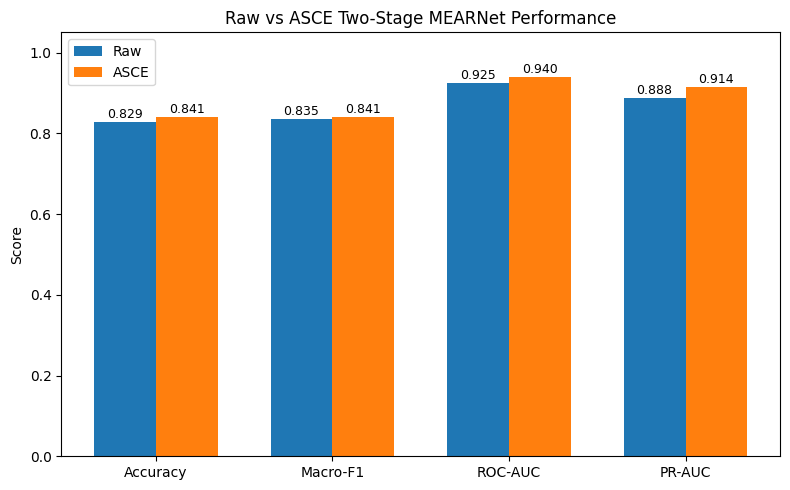

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_raw_vs_asce_performance.png


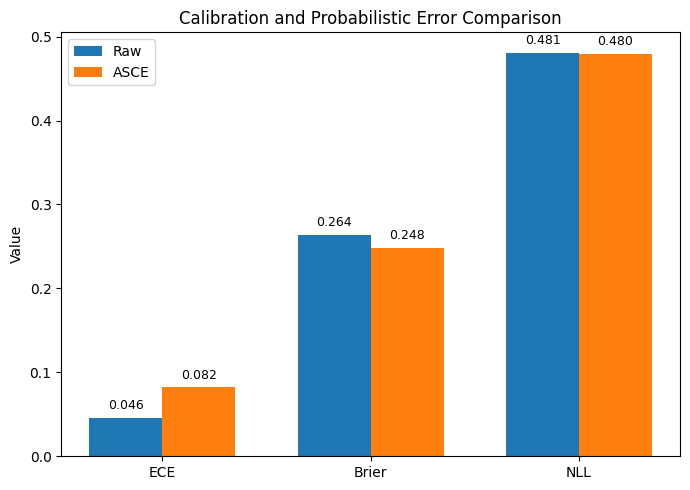

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_raw_vs_asce_calibration.png


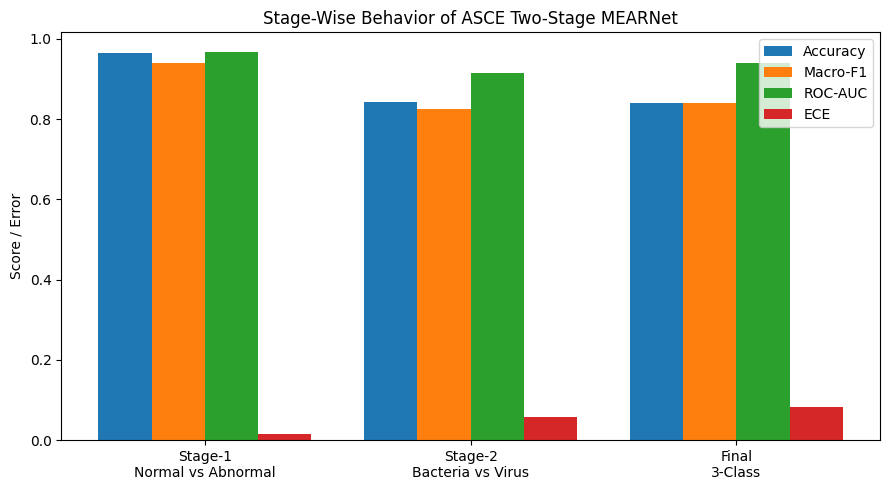

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_stagewise_metrics.png


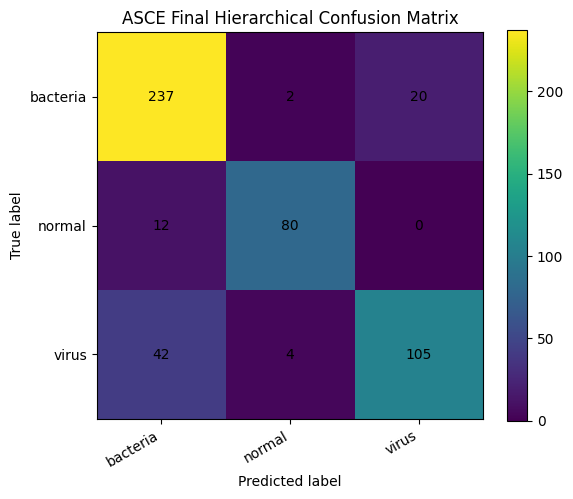

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_confusion_matrix.png


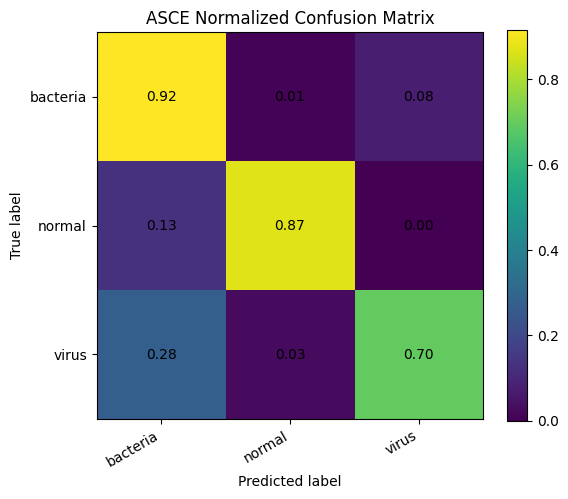

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_normalized_confusion_matrix.png


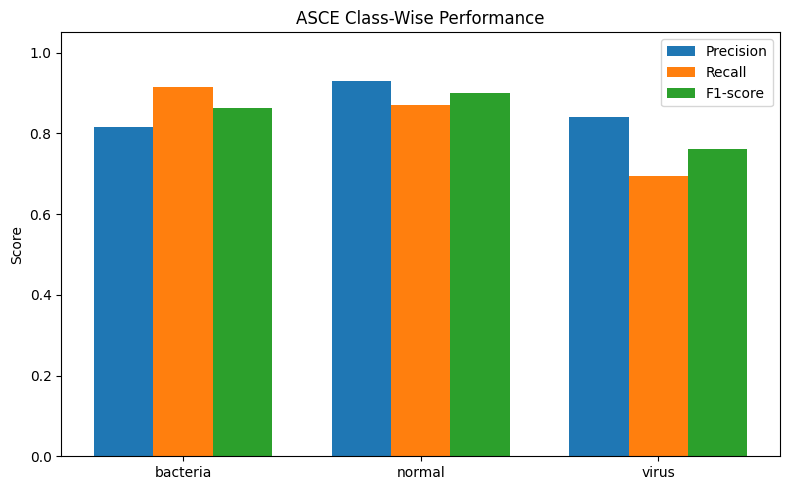

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_classwise_performance.png


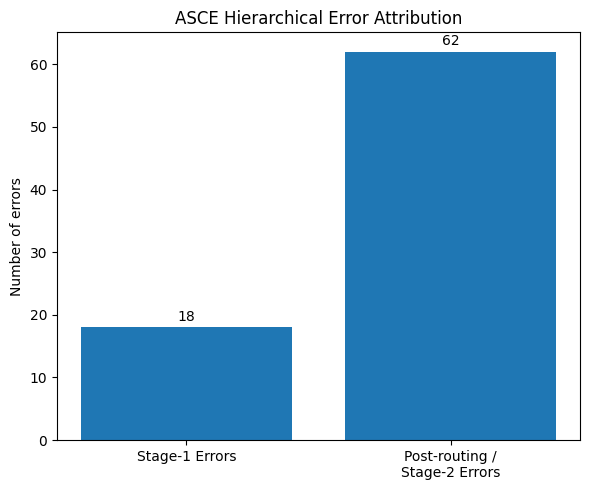

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_error_attribution.png


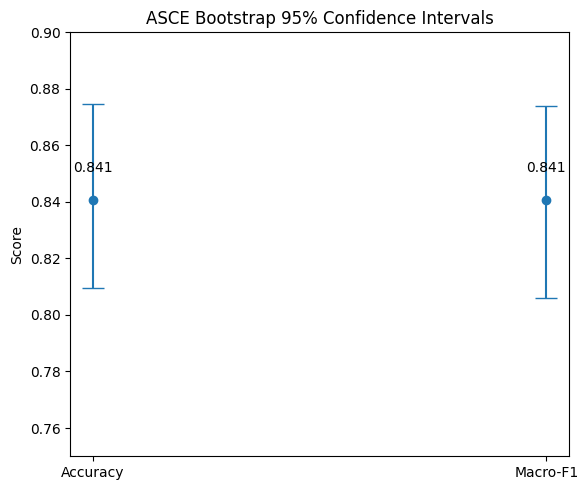

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_bootstrap_ci.png


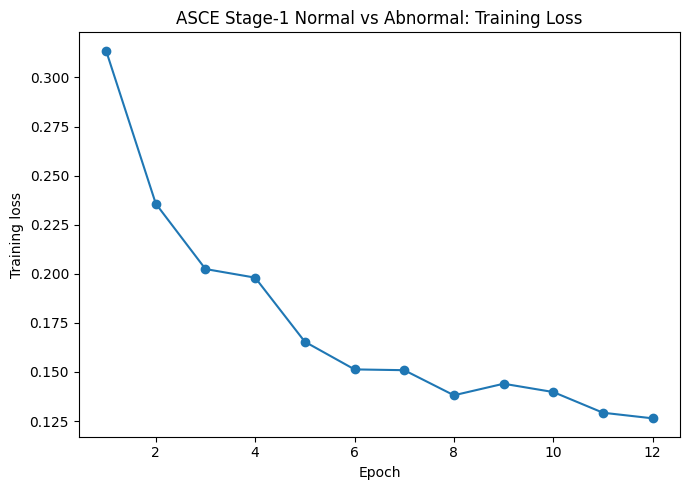

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_stage1_training_loss.png


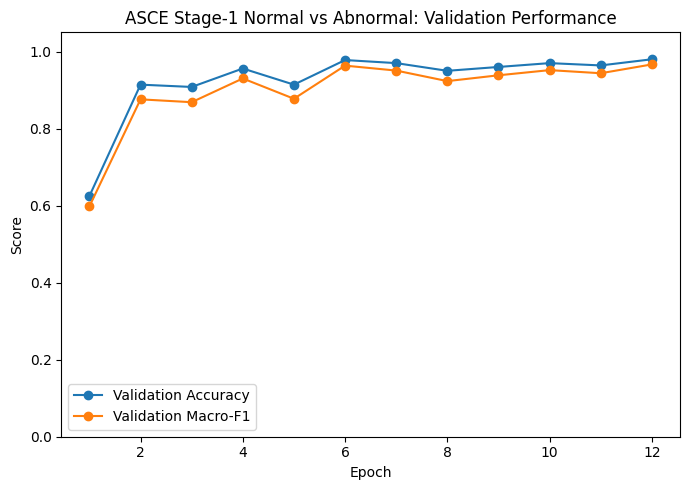

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_stage1_validation_curves.png


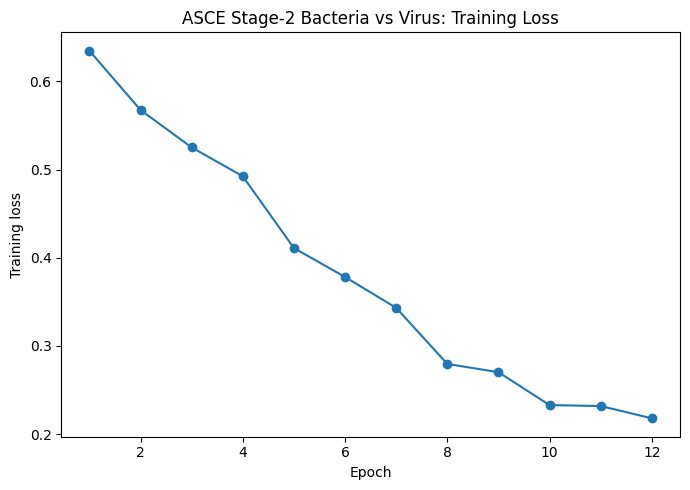

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_stage2_training_loss.png


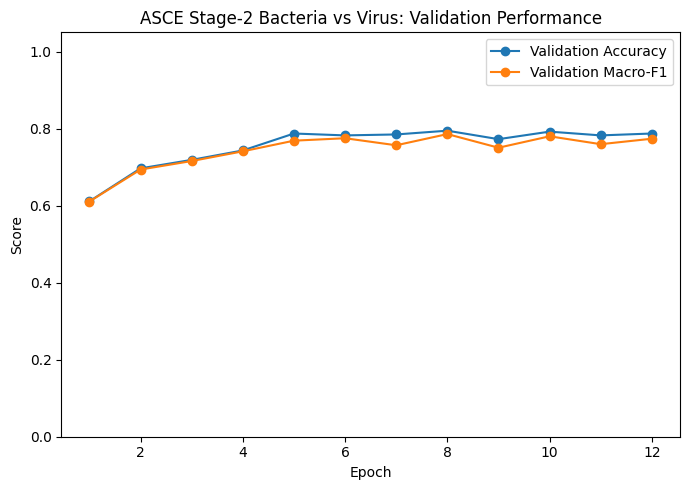

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_stage2_validation_curves.png


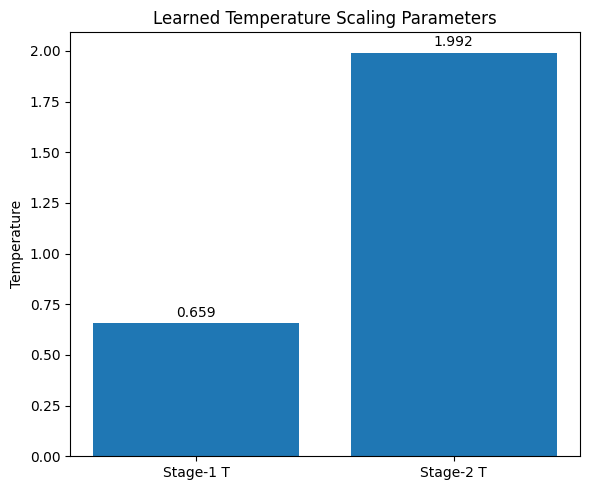

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_temperature_scaling.png


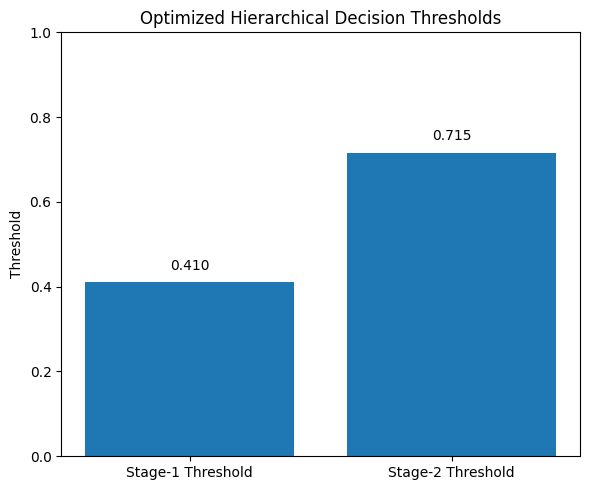

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_asce_thresholds.png

Validation summary saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/methodsx_validation_summary.csv


,Protocol,Accuracy,Macro-F1,ROC-AUC,PR-AUC,ECE,Brier,NLL
0,Raw two-stage MEARNet,0.828685,0.835443,0.925145,0.888425,0.045779,0.263924,0.481013
1,ASCE two-stage MEARNet,0.840637,0.840521,0.939586,0.914405,0.082118,0.248432,0.479712



All MethodsX figures saved in: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures


In [5]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt


FIG_DIR = "/content/drive/MyDrive/mearnet_reproducible_outputs/methods_figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)



raw_metrics = {
    "accuracy": 0.8286852589641435,
    "macro_f1": 0.8354433441973463,
    "roc_auc": 0.9251447775134177,
    "pr_auc_macro": 0.8884246829620371,
    "ece": 0.04577856157642912,
    "brier": 0.2639236111510313,
    "nll": 0.4810130506662232
}


ASCE_JSON = "/content/drive/MyDrive/mearnet_reproducible_outputs/two_stage/two_stage_test_metrics.json"

try:
    asce_metrics = metrics
    print("Using current variable: metrics")
except NameError:
    if os.path.exists(ASCE_JSON):
        with open(ASCE_JSON, "r") as f:
            asce_metrics = json.load(f)
        print("Loaded ASCE metrics from:", ASCE_JSON)
    else:
        raise FileNotFoundError("No metrics variable found and ASCE JSON file not found.")


metric_keys = ["accuracy", "macro_f1", "roc_auc", "pr_auc_macro"]
metric_labels = ["Accuracy", "Macro-F1", "ROC-AUC", "PR-AUC"]

raw_vals = [raw_metrics[k] for k in metric_keys]
asce_vals = [asce_metrics[k] for k in metric_keys]

x = np.arange(len(metric_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, raw_vals, width, label="Raw")
plt.bar(x + width/2, asce_vals, width, label="ASCE")
plt.xticks(x, metric_labels)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Raw vs ASCE Two-Stage MEARNet Performance")
plt.legend()

for i, v in enumerate(raw_vals):
    plt.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(asce_vals):
    plt.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

savefig("fig_raw_vs_asce_performance.png")



cal_keys = ["ece", "brier", "nll"]
cal_labels = ["ECE", "Brier", "NLL"]

raw_cal = [raw_metrics[k] for k in cal_keys]
asce_cal = [asce_metrics[k] for k in cal_keys]

x = np.arange(len(cal_labels))

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, raw_cal, width, label="Raw")
plt.bar(x + width/2, asce_cal, width, label="ASCE")
plt.xticks(x, cal_labels)
plt.ylabel("Value")
plt.title("Calibration and Probabilistic Error Comparison")
plt.legend()

for i, v in enumerate(raw_cal):
    plt.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(asce_cal):
    plt.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

savefig("fig_raw_vs_asce_calibration.png")



stage_names = ["Stage-1\nNormal vs Abnormal", "Stage-2\nBacteria vs Virus", "Final\n3-Class"]
stage_metrics = [
    asce_metrics["stage1_test"],
    asce_metrics["stage2_test"],
    asce_metrics
]

stage_metric_keys = ["accuracy", "macro_f1", "roc_auc", "ece"]
stage_metric_labels = ["Accuracy", "Macro-F1", "ROC-AUC", "ECE"]

x = np.arange(len(stage_names))
width = 0.2

plt.figure(figsize=(9, 5))

for j, key in enumerate(stage_metric_keys):
    vals = [m[key] for m in stage_metrics]
    plt.bar(x + (j - 1.5) * width, vals, width, label=stage_metric_labels[j])

plt.xticks(x, stage_names)
plt.ylabel("Score / Error")
plt.title("Stage-Wise Behavior of ASCE Two-Stage MEARNet")
plt.legend()

savefig("fig_asce_stagewise_metrics.png")


classes = ["bacteria", "normal", "virus"]
cm = np.array(asce_metrics["confusion_matrix"])

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("ASCE Final Hierarchical Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(len(classes)), classes, rotation=30, ha="right")
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
savefig("fig_asce_confusion_matrix.png")


cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm)
plt.title("ASCE Normalized Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(len(classes)), classes, rotation=30, ha="right")
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

plt.colorbar()
savefig("fig_asce_normalized_confusion_matrix.png")



report = asce_metrics["classification_report"]

precision = [report[c]["precision"] for c in classes]
recall = [report[c]["recall"] for c in classes]
f1 = [report[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, classes)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("ASCE Class-Wise Performance")
plt.legend()

savefig("fig_asce_classwise_performance.png")



err = asce_metrics["error_attribution"]

error_labels = ["Stage-1 Errors", "Post-routing /\nStage-2 Errors"]
error_vals = [
    err["stage1_errors"],
    err["post_routing_or_stage2_errors_estimated"]
]

plt.figure(figsize=(6, 5))
plt.bar(error_labels, error_vals)
plt.ylabel("Number of errors")
plt.title("ASCE Hierarchical Error Attribution")

for i, v in enumerate(error_vals):
    plt.text(i, v + 1, str(v), ha="center", fontsize=10)

savefig("fig_asce_error_attribution.png")



boot = asce_metrics["bootstrap"]

ci_labels = ["Accuracy", "Macro-F1"]
point_vals = [asce_metrics["accuracy"], asce_metrics["macro_f1"]]
ci_low = [boot["accuracy_95ci"][0], boot["macro_f1_95ci"][0]]
ci_high = [boot["accuracy_95ci"][1], boot["macro_f1_95ci"][1]]

yerr_lower = np.array(point_vals) - np.array(ci_low)
yerr_upper = np.array(ci_high) - np.array(point_vals)

x = np.arange(len(ci_labels))

plt.figure(figsize=(6, 5))
plt.errorbar(x, point_vals, yerr=[yerr_lower, yerr_upper], fmt="o", capsize=8)
plt.xticks(x, ci_labels)
plt.ylim(0.75, 0.90)
plt.ylabel("Score")
plt.title("ASCE Bootstrap 95% Confidence Intervals")

for i, v in enumerate(point_vals):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

savefig("fig_asce_bootstrap_ci.png")


def plot_training_curves(history, title_prefix, filename_prefix):
    epochs = [h["epoch"] for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_acc = [h["val_acc"] for h in history]
    val_f1 = [h["val_macro_f1"] for h in history]

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, train_loss, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"{title_prefix}: Training Loss")
    savefig(f"{filename_prefix}_training_loss.png")

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, val_acc, marker="o", label="Validation Accuracy")
    plt.plot(epochs, val_f1, marker="o", label="Validation Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.title(f"{title_prefix}: Validation Performance")
    plt.legend()
    savefig(f"{filename_prefix}_validation_curves.png")

plot_training_curves(
    asce_metrics["stage1_train_info"]["history"],
    "ASCE Stage-1 Normal vs Abnormal",
    "fig_asce_stage1"
)

plot_training_curves(
    asce_metrics["stage2_train_info"]["history"],
    "ASCE Stage-2 Bacteria vs Virus",
    "fig_asce_stage2"
)



temp_labels = ["Stage-1 T", "Stage-2 T"]
temp_vals = [
    asce_metrics["stage1_temperature"],
    asce_metrics["stage2_temperature"]
]

plt.figure(figsize=(6, 5))
plt.bar(temp_labels, temp_vals)
plt.ylabel("Temperature")
plt.title("Learned Temperature Scaling Parameters")

for i, v in enumerate(temp_vals):
    plt.text(i, v + 0.03, f"{v:.3f}", ha="center")

savefig("fig_asce_temperature_scaling.png")

thr_labels = ["Stage-1 Threshold", "Stage-2 Threshold"]
thr_vals = [
    asce_metrics["stage1_threshold"],
    asce_metrics["stage2_threshold"]
]

plt.figure(figsize=(6, 5))
plt.bar(thr_labels, thr_vals)
plt.ylim(0, 1.0)
plt.ylabel("Threshold")
plt.title("Optimized Hierarchical Decision Thresholds")

for i, v in enumerate(thr_vals):
    plt.text(i, v + 0.03, f"{v:.3f}", ha="center")

savefig("fig_asce_thresholds.png")



import pandas as pd

summary_rows = [
    {
        "Protocol": "Raw two-stage MEARNet",
        "Accuracy": raw_metrics["accuracy"],
        "Macro-F1": raw_metrics["macro_f1"],
        "ROC-AUC": raw_metrics["roc_auc"],
        "PR-AUC": raw_metrics["pr_auc_macro"],
        "ECE": raw_metrics["ece"],
        "Brier": raw_metrics["brier"],
        "NLL": raw_metrics["nll"]
    },
    {
        "Protocol": "ASCE two-stage MEARNet",
        "Accuracy": asce_metrics["accuracy"],
        "Macro-F1": asce_metrics["macro_f1"],
        "ROC-AUC": asce_metrics["roc_auc"],
        "PR-AUC": asce_metrics["pr_auc_macro"],
        "ECE": asce_metrics["ece"],
        "Brier": asce_metrics["brier"],
        "NLL": asce_metrics["nll"]
    }
]

df_summary = pd.DataFrame(summary_rows)
csv_path = os.path.join(FIG_DIR, "methodsx_validation_summary.csv")
df_summary.to_csv(csv_path, index=False)

print("\nValidation summary saved:", csv_path)
display(df_summary)

print("\nAll MethodsX figures saved in:", FIG_DIR)

In [11]:
import os
import json
import numpy as np
import torch


try:
    cfg
    print("Using existing cfg object.")
except NameError:
    cfg = Config(
        image_root="/content/drive/MyDrive/Lung_data/ASCE_final_processed",
        mask_root="/content/drive/MyDrive/Lung_data/mask",
        output_dir="/content/drive/MyDrive/mearnet_reproducible_outputs",
        mode="two_stage",
        backbone="convnext_tiny",
        enhance_on_fly=False,
        tta_flip=False,
        epochs_s1=12,
        epochs_s2=12,
    )
    print("Created cfg object manually.")

OUTDIR = os.path.join(cfg.output_dir, "two_stage")
METRICS_JSON = os.path.join(OUTDIR, "two_stage_test_metrics.json")
NPZ_PATH = os.path.join(OUTDIR, "two_stage_test_predictions.npz")



if "metrics" in globals():
    run_metrics = metrics
    print("Using current metrics variable.")
else:
    with open(METRICS_JSON, "r") as f:
        run_metrics = json.load(f)
    print("Loaded metrics from:", METRICS_JSON)

T1 = float(run_metrics["stage1_temperature"])
T2 = float(run_metrics["stage2_temperature"])
t1 = float(run_metrics["stage1_threshold"])
t2 = float(run_metrics["stage2_threshold"])

print(f"Stage-1 T={T1:.4f}, threshold={t1:.3f}")
print(f"Stage-2 T={T2:.4f}, threshold={t2:.3f}")


samples, splits = prepare_splits(cfg)

s1_dsets = make_task_datasets(cfg, splits, task="stage1")
s2_dsets = make_task_datasets(cfg, splits, task="stage2")

s1_test_loader = make_loader(
    s1_dsets["test"],
    cfg.batch_size,
    cfg.num_workers,
    weighted=False
)

s2_test_loader = make_loader(
    s2_dsets["test"],
    cfg.batch_size,
    cfg.num_workers,
    weighted=False
)

device = cfg.device

s1_model = MEARNet(cfg, num_classes=2).to(device)
s2_model = MEARNet(cfg, num_classes=2).to(device)

s1_ckpt = os.path.join(OUTDIR, "best_stage1.pt")
s2_ckpt = os.path.join(OUTDIR, "best_stage2.pt")

s1_state = torch.load(s1_ckpt, map_location=device)
s2_state = torch.load(s2_ckpt, map_location=device)

s1_model.load_state_dict(s1_state["model"])
s2_model.load_state_dict(s2_state["model"])

s1_model.eval()
s2_model.eval()

print("Loaded checkpoints:")
print(s1_ckpt)
print(s2_ckpt)

s1_pack = collect_logits(
    s1_model,
    s1_test_loader,
    device,
    tta_flip=cfg.tta_flip,
    temperature=T1
)

s2_pack = collect_logits(
    s2_model,
    s2_test_loader,
    device,
    tta_flip=cfg.tta_flip,
    temperature=T2
)


s2_prob_by_idx = {
    int(idx): p for idx, p in zip(s2_pack["base_idx"], s2_pack["probs"])
}

n = len(s1_pack["y3"])
y_true = s1_pack["y3"].astype(np.int64)

probs3 = np.zeros((n, 3), dtype=np.float32)
pred3 = np.zeros(n, dtype=np.int64)

for i in range(n):
    p1 = s1_pack["probs"][i]     # [P(normal), P(abnormal)]
    p_normal = float(p1[0])
    p_abn = float(p1[1])
    base_idx = int(s1_pack["base_idx"][i])

    if base_idx in s2_prob_by_idx:
        p2 = s2_prob_by_idx[base_idx]   # [P(bacteria), P(virus)]
    else:
        p2 = np.array([0.5, 0.5], dtype=np.float32)

    probs3[i, 1] = p_normal
    probs3[i, 0] = p_abn * float(p2[0])
    probs3[i, 2] = p_abn * float(p2[1])
    probs3[i] = probs3[i] / np.clip(probs3[i].sum(), 1e-8, None)

    if p_abn < t1:
        pred3[i] = 1       # normal
    else:
        pred3[i] = 2 if float(p2[1]) >= t2 else 0


np.savez(
    NPZ_PATH,
    y_true=y_true,
    pred=pred3,
    probs=probs3,
    stage1_y=s1_pack["y"],
    stage1_probs=s1_pack["probs"],
    stage2_y=s2_pack["y"],
    stage2_probs=s2_pack["probs"],
    fname=s1_pack["fname"],
    base_idx=s1_pack["base_idx"]
)

print("Saved prediction arrays to:")
print(NPZ_PATH)

print("Final prediction array shapes:")
print("y_true:", y_true.shape)
print("pred:", pred3.shape)
print("probs:", probs3.shape)
print("stage1_probs:", s1_pack["probs"].shape)
print("stage2_probs:", s2_pack["probs"].shape)

Using existing cfg object.
Using current metrics variable.
Stage-1 T=0.6590, threshold=0.410
Stage-2 T=1.9918, threshold=0.715
Loaded checkpoints:
/content/drive/MyDrive/mearnet_reproducible_outputs/two_stage/best_stage1.pt
/content/drive/MyDrive/mearnet_reproducible_outputs/two_stage/best_stage2.pt
Saved prediction arrays to:
/content/drive/MyDrive/mearnet_reproducible_outputs/two_stage/two_stage_test_predictions.npz
Final prediction array shapes:
y_true: (502,)
pred: (502,)
probs: (502, 3)
stage1_probs: (502, 2)
stage2_probs: (410, 2)


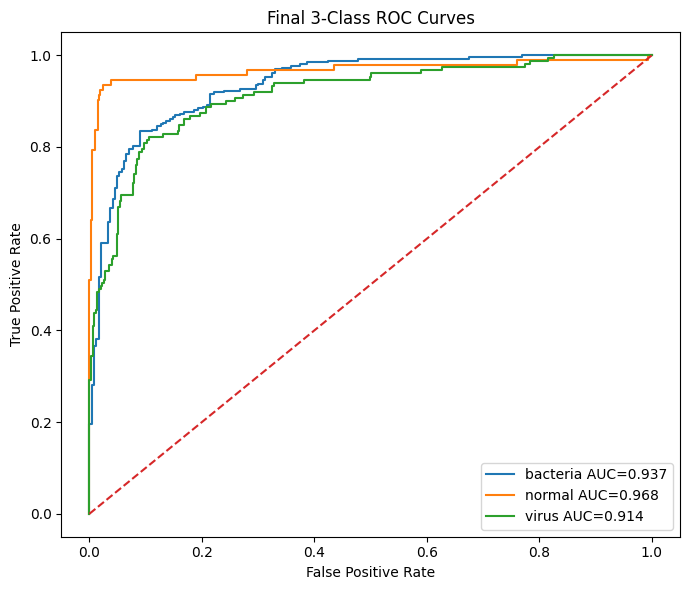

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_final_roc_curves.png


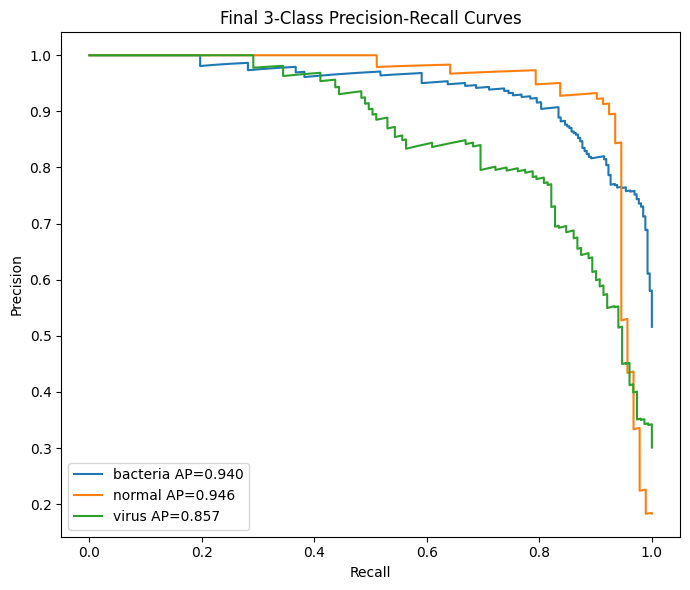

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_final_pr_curves.png


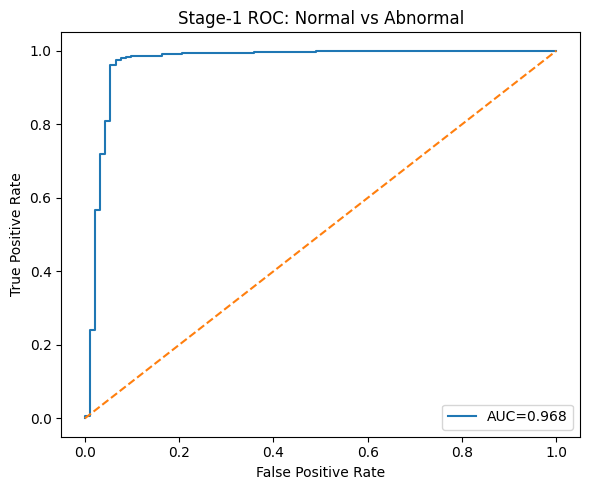

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_stage1_roc.png


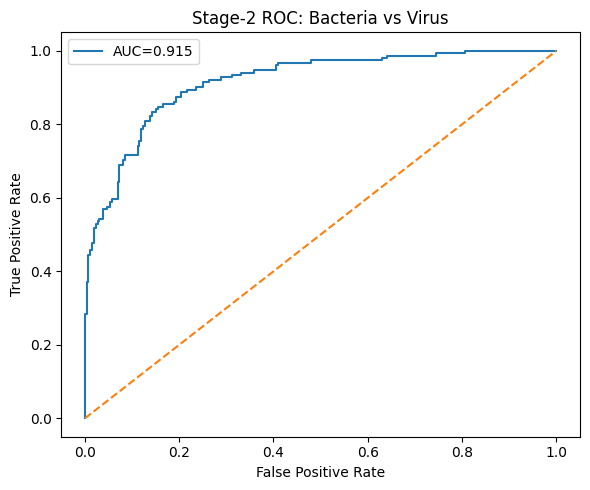

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_stage2_roc.png


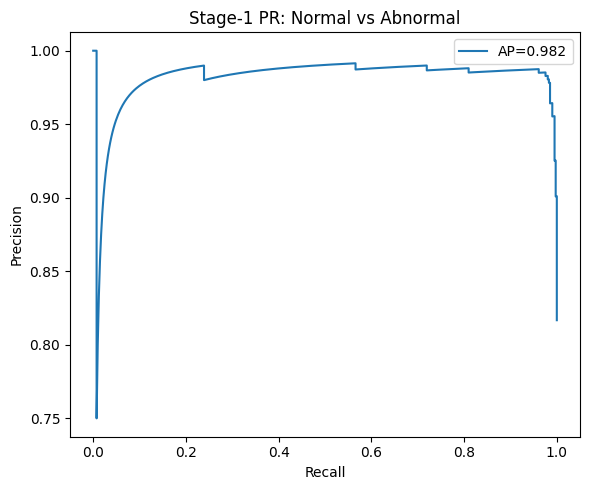

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_stage1_pr.png


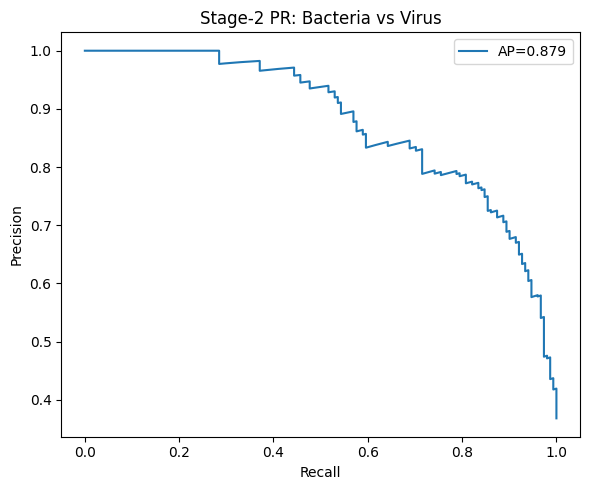

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_stage2_pr.png


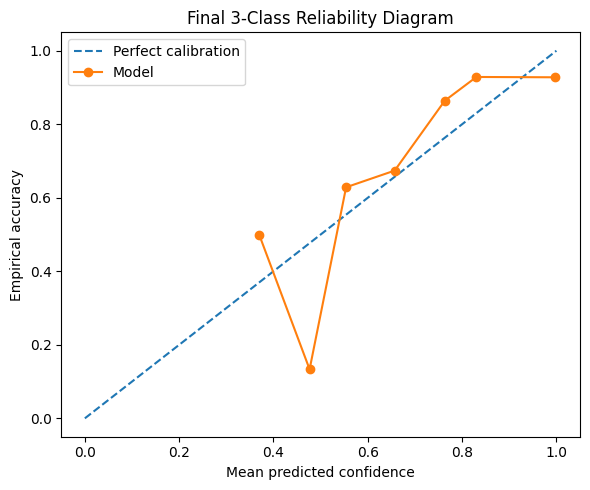

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_final_reliability_diagram.png


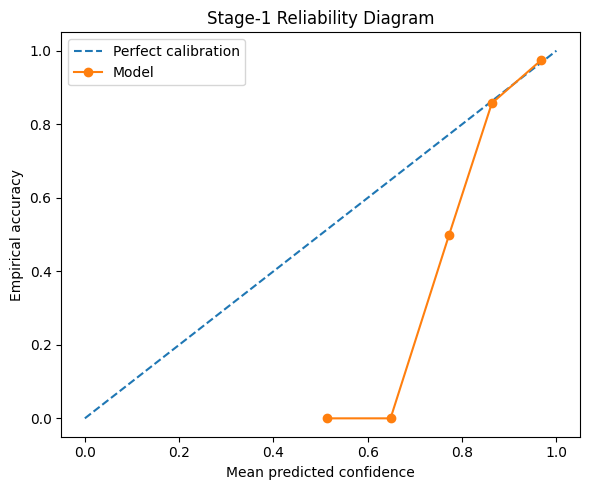

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_stage1_reliability_diagram.png


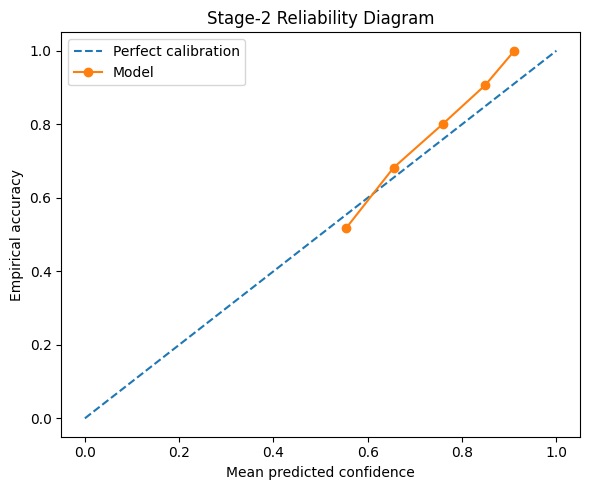

Saved: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures/fig_stage2_reliability_diagram.png
ROC, PR, and reliability figures saved in: /content/drive/MyDrive/mearnet_reproducible_outputs/methodsx_figures


In [12]:


import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

FIG_DIR = "/content/drive/MyDrive/mearnet_reproducible_outputs/methods_figures"
NPZ_PATH = "/content/drive/MyDrive/mearnet_reproducible_outputs/two_stage/two_stage_test_predictions.npz"

os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

pack = np.load(NPZ_PATH)

y_true = pack["y_true"]
probs = pack["probs"]
stage1_y = pack["stage1_y"]
stage1_probs = pack["stage1_probs"]
stage2_y = pack["stage2_y"]
stage2_probs = pack["stage2_probs"]

classes = ["bacteria", "normal", "virus"]


plt.figure(figsize=(7, 6))

for c, cname in enumerate(classes):
    y_bin = (y_true == c).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, probs[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname} AUC={roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final 3-Class ROC Curves")
plt.legend()

savefig("fig_final_roc_curves.png")



plt.figure(figsize=(7, 6))

for c, cname in enumerate(classes):
    y_bin = (y_true == c).astype(int)
    precision, recall, _ = precision_recall_curve(y_bin, probs[:, c])
    ap = average_precision_score(y_bin, probs[:, c])
    plt.plot(recall, precision, label=f"{cname} AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final 3-Class Precision-Recall Curves")
plt.legend()

savefig("fig_final_pr_curves.png")



def plot_binary_roc(y, p_pos, title, filename):
    fpr, tpr, _ = roc_curve(y, p_pos)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    savefig(filename)

plot_binary_roc(
    stage1_y,
    stage1_probs[:, 1],
    "Stage-1 ROC: Normal vs Abnormal",
    "fig_stage1_roc.png"
)

plot_binary_roc(
    stage2_y,
    stage2_probs[:, 1],
    "Stage-2 ROC: Bacteria vs Virus",
    "fig_stage2_roc.png"
)



def plot_binary_pr(y, p_pos, title, filename):
    precision, recall, _ = precision_recall_curve(y, p_pos)
    ap = average_precision_score(y, p_pos)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    savefig(filename)

plot_binary_pr(
    stage1_y,
    stage1_probs[:, 1],
    "Stage-1 PR: Normal vs Abnormal",
    "fig_stage1_pr.png"
)

plot_binary_pr(
    stage2_y,
    stage2_probs[:, 1],
    "Stage-2 PR: Bacteria vs Virus",
    "fig_stage2_pr.png"
)



def plot_reliability(y, probs, title, filename, n_bins=10):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_conf = []
    bin_acc = []
    bin_count = []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == 0:
            mask = (conf >= lo) & (conf <= hi)
        else:
            mask = (conf > lo) & (conf <= hi)

        if np.any(mask):
            bin_conf.append(conf[mask].mean())
            bin_acc.append(correct[mask].mean())
            bin_count.append(mask.sum())

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.plot(bin_conf, bin_acc, marker="o", label="Model")
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Empirical accuracy")
    plt.title(title)
    plt.legend()
    savefig(filename)

plot_reliability(
    y_true,
    probs,
    "Final 3-Class Reliability Diagram",
    "fig_final_reliability_diagram.png"
)

plot_reliability(
    stage1_y,
    stage1_probs,
    "Stage-1 Reliability Diagram",
    "fig_stage1_reliability_diagram.png"
)

plot_reliability(
    stage2_y,
    stage2_probs,
    "Stage-2 Reliability Diagram",
    "fig_stage2_reliability_diagram.png"
)

print("ROC, PR, and reliability figures saved in:", FIG_DIR)